Import libraries

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

Load Reuters dataset

In [ ]:
max_words = 10000

(X_train, y_train), (X_test, y_test) = reuters.load_data(
    num_words=max_words
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 8982
Testing samples: 2246


Create word index

In [ ]:
word_index = reuters.get_word_index()

reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


Convert dataset into text

In [ ]:
texts = []

for sequence in X_train[:1000]:
    words = []

    for index in sequence:
        words.append(reverse_word_index.get(index, "?"))

    texts.append(" ".join(words))

print(texts[0])

<START> <UNK> <UNK> said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


Create tokenizer

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(texts)

total_words = len(tokenizer.word_index) + 1

print("Total vocabulary:", total_words)

Total vocabulary: 7470


Create sequences

In [ ]:
input_sequences = []

for text in texts:
    token_list = tokenizer.texts_to_sequences([text])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

print("Total sequences:", len(input_sequences))


Total sequences: 146533


Padding

In [ ]:
max_sequence_len = 30

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding='pre'
)

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (146533, 29)
y shape: (146533,)


Build LSTM model

In [ ]:
model = Sequential([
    Embedding(
        total_words,
        100,
        input_length=max_sequence_len - 1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train

In [ ]:
history = model.fit(
    X,
    y,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.0698 - loss: 6.6347 - val_accuracy: 0.1029 - val_loss: 6.3811
Epoch 2/5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.1298 - loss: 5.9216 - val_accuracy: 0.1503 - val_loss: 5.9826
Epoch 3/5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.1628 - loss: 5.5045 - val_accuracy: 0.1688 - val_loss: 5.7881
Epoch 4/5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.1834 - loss: 5.2152 - val_accuracy: 0.1823 - val_loss: 5.6819
Epoch 5/5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.1999 - loss: 4.9885 - val_accuracy: 0.1920 - val_loss: 5.6177


Plot accuracy

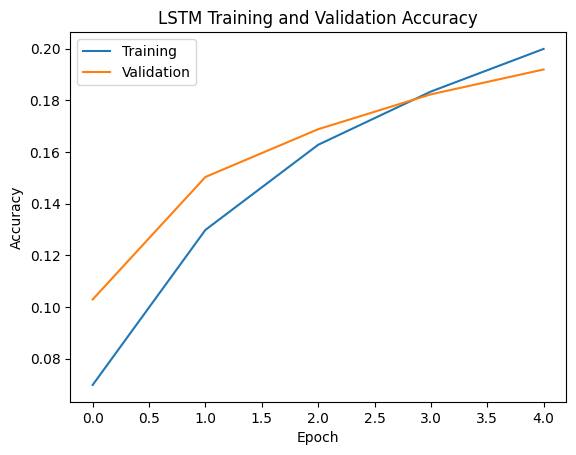

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

Next-word prediction

In [ ]:
def predict_next_word(seed_text):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len - 1,
        padding='pre'
    )

    predicted = model.predict(
        token_list,
        verbose=0
    )

    predicted_word_index = np.argmax(predicted, axis=1)[0]

    for word, index in tokenizer.word_index.items():

        if index == predicted_word_index:
            return word

    return "Unknown"

Test

In [ ]:
seed_text = "the company"

next_word = predict_next_word(seed_text)

print("Input:", seed_text)
print("Predicted next word:", next_word)

Input: the company
Predicted next word: said


Generate a sentence

In [ ]:
def generate_text(seed_text, num_words=5):

    for _ in range(num_words):

        next_word = predict_next_word(seed_text)

        seed_text += " " + next_word

    return seed_text


print(generate_text("the company", 5))

the company aviation hampered aviation artificially counterpart
